Loading cleaned dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df= pd.read_csv('C:/Mumbai_Real_Estate_Intelligence/data/cleaned/mumbai_housing_price_cleaned.csv')
df_model= df.copy()
df_model.head()


,Year,Price_per_sqm_Local,Size_sqm,Bedrooms,Total_Price_Local,Area_Bandra,Area_Borivali,Area_Colaba,Area_Powai
0,2020,163782,139,2,22765698,0,0,0,0
1,2021,214723,71,4,15245333,0,0,0,0
2,2019,349044,218,5,76091592,1,0,0,0
3,2021,296588,152,6,45081376,0,0,1,0
4,2025,371440,203,6,75402320,0,0,1,0


Feature & Target Selection

In [26]:
X= df_model.drop('Total_Price_Local', axis=1)
y=df_model['Total_Price_Local']
X.head()

,Year,Price_per_sqm_Local,Size_sqm,Bedrooms,Area_Bandra,Area_Borivali,Area_Colaba,Area_Powai
0,2020,163782,139,2,0,0,0,0
1,2021,214723,71,4,0,0,0,0
2,2019,349044,218,5,1,0,0,0
3,2021,296588,152,6,0,0,1,0
4,2025,371440,203,6,0,0,1,0


Training Data

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)


Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

XGBoost

In [29]:
from xgboost import XGBRegressor
xgb= XGBRegressor(n_estimator= 500, learning_rate= 0.05, max_depth= 6, subsample= 0.8, colsample_bytree= 0.8, random_state= 42)
xgb.fit(X_train, y_train)
xgb_pred= xgb.predict(X_test)

c:\Mumbai_Real_Estate_Intelligence\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:04:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation

In [30]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    r2 = r2_score(y_true,y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

Model Comparision

In [31]:
results = []

results.append(evaluate_model("Random Forest", y_test,rf_pred))

results.append(evaluate_model("XGBoost", y_test, xgb_pred))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Random Forest,3.203955e+06,4.010425e+06,0.982121
1,XGBoost,5.115104e+06,6.379132e+06,0.954765


Hyperprameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [300,500]
}

xgb_grid = GridSearchCV(estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters for XGBoost:", xgb_grid.best_params_)
print("Best R2:", xgb_grid.best_score_)


Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500}
Best R2: 0.9803962230682373


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)

print("Best R2:", rf_grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Best R2: 0.9707619297692652


Best Model

In [34]:
best_rf = rf_grid.best_estimator_
print(best_rf)
best_xgb = xgb_grid.best_estimator_
print(best_xgb)

RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [35]:
rf_pred_tuned = best_rf.predict(X_test)
print(rf_pred_tuned)
xgb_pred_tuned = best_xgb.predict(X_test)
print(xgb_pred_tuned)

[4.58712655e+07 3.36755275e+07 2.91822361e+07 9.99067465e+07
 1.67396060e+07 5.02614648e+07 2.28050406e+07 1.67847779e+07
 3.76411473e+07 6.09486511e+07 3.79489404e+07 3.64564197e+07
 8.40823897e+07 5.57383039e+07 4.13625555e+07 5.44669752e+07
 6.31024512e+07 3.27463997e+07 2.38362300e+07 5.56257962e+07
 1.29362484e+08 5.40240456e+07 3.57727846e+07 7.50207093e+06
 5.19909162e+07 8.44643337e+07 6.30934564e+07 6.45564829e+07
 3.12606876e+07 2.47010148e+07 9.96774959e+07 4.82813352e+07
 1.25708076e+07 1.12355226e+08 4.61041921e+07 3.78303597e+07
 1.31680533e+07 1.88345259e+07 3.63299706e+07 2.17048646e+07
 1.20430098e+07 6.72011541e+07 4.10551394e+07 4.69779519e+07
 1.09095331e+08 1.71584094e+07]
[5.1094484e+07 3.1002184e+07 2.8108314e+07 9.9404808e+07 1.3290195e+07
 5.0178584e+07 2.1887258e+07 1.7792510e+07 3.8093484e+07 5.9052904e+07
 3.6249924e+07 3.7883588e+07 8.4707240e+07 5.4631204e+07 4.1160184e+07
 5.9250544e+07 6.4280452e+07 3.0766856e+07 2.4769612e+07 5.7608168e+07
 1.4060939e+0

In [36]:
evaluate_model("Tuned Random Forest", y_test, rf_pred_tuned)

{'Model': 'Tuned Random Forest',
 'MAE': 3002499.8504951005,
 'RMSE': np.float64(3769172.123944985),
 'R2': 0.9842076230587802}

In [37]:
evaluate_model("Tuned XGBoost", y_test, xgb_pred_tuned)

{'Model': 'Tuned XGBoost',
 'MAE': 2096137.625,
 'RMSE': np.float64(2643581.889700412),
 'R2': 0.9922314286231995}

After tuning results

In [38]:
results2 = []

models = [
    ("Tuned Random Forest", rf_pred_tuned),
    ("Tuned XGBoost", xgb_pred_tuned)
]

for model_name, pred in models:
     results2.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results2)

print(results_df)

                 Model           MAE          RMSE        R2
0  Tuned Random Forest  3.002500e+06  3.769172e+06  0.984208
1        Tuned XGBoost  2.096138e+06  2.643582e+06  0.992231


In [39]:
if r2_score(y_test, rf_pred_tuned) > r2_score(y_test, xgb_pred_tuned):
    final_model = best_rf
    print("Random Forest Selected")
else:
    final_model = best_xgb
    print("XGBoost Selected")

XGBoost Selected


Feature Importance Analysis

In [40]:
importance_df_model = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

importance_df_model = importance_df_model.sort_values(
    by="Importance",
    ascending=False
)

importance_df_model

,Feature,Importance
2,Size_sqm,0.555383
1,Price_per_sqm_Local,0.440998
4,Area_Bandra,0.000753
3,Bedrooms,0.000734
0,Year,0.000611
7,Area_Powai,0.000584
5,Area_Borivali,0.000487
6,Area_Colaba,0.000448


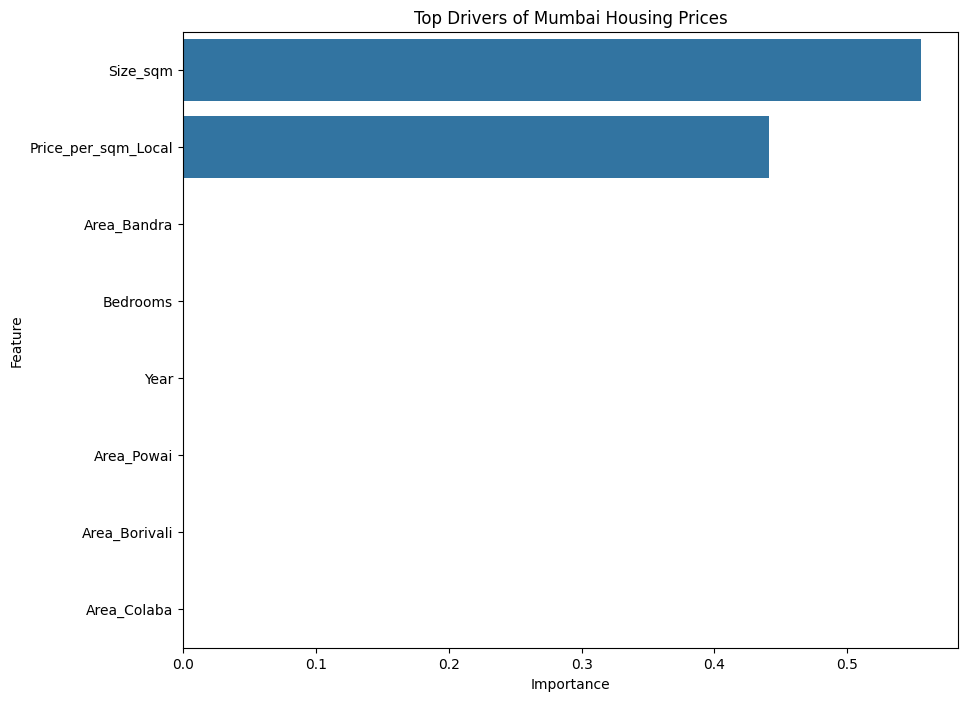

In [41]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df_model.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Drivers of Mumbai Housing Prices")

plt.show()

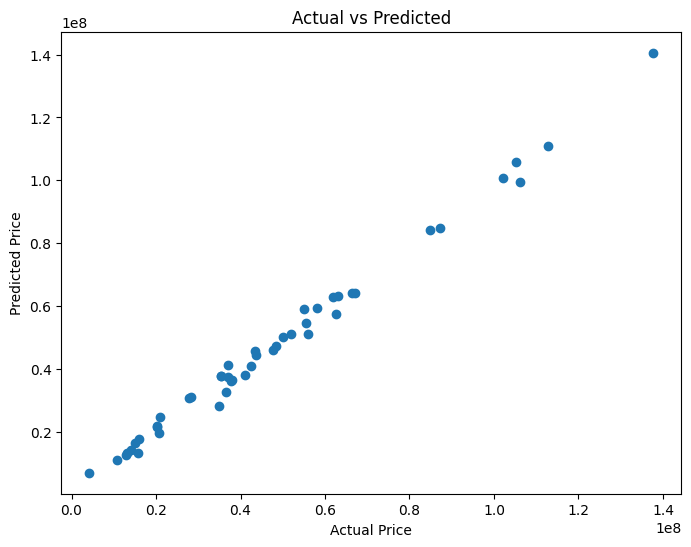

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred_tuned
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -----------------

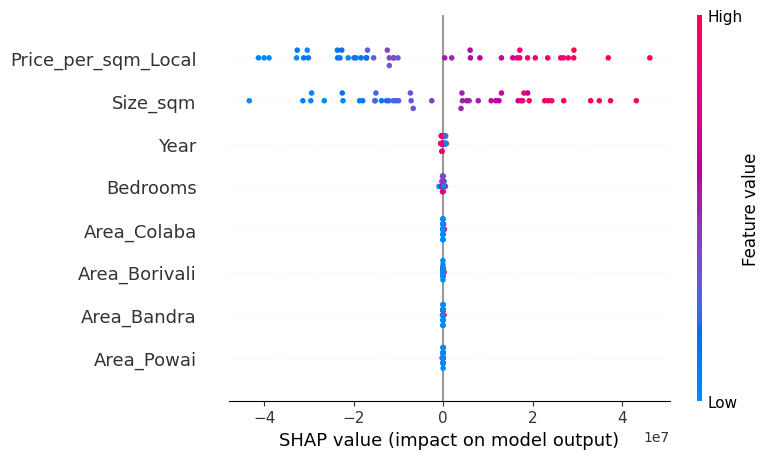

In [ ]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

Which features increase prices & which features decrease prices

In [ ]:
import pickle

with open(
    "../models/final_xgboost_model.pkl",
    "wb"
) as file:

    pickle.dump(best_xgb, file)

print("Model Saved Successfully")

Model Saved Successfully


In [42]:
importance_df_model.to_csv(
    "../data/cleaned/feature_importance.csv",
    index=False
)

In [43]:
X.columns


Index(['Year', 'Price_per_sqm_Local', 'Size_sqm', 'Bedrooms', 'Area_Bandra',
       'Area_Borivali', 'Area_Colaba', 'Area_Powai'],
      dtype='str')